In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm

plt.style.use('ggplot')

# Nonlinear Regression

In the previous notebook, we incorporated link functions to extend the usage of regression models. This way, although the relationship between the predictors and the response variable becomes nonlinear, the predictors still connect with the link function linearly. In this notebook, we will introduce nonlinearity directly through the predictors.

Let's create a dataset we will use in this notebook and start with the model definitions.

**Dataset**

$n = 200$

$x \sim U(0, 10)$

$y = \sin(x) + 0.3\,x - 0.05\,x^2 + 2 + \varepsilon$

$\varepsilon \sim \mathcal{N}(0,\ 0.5^2)$


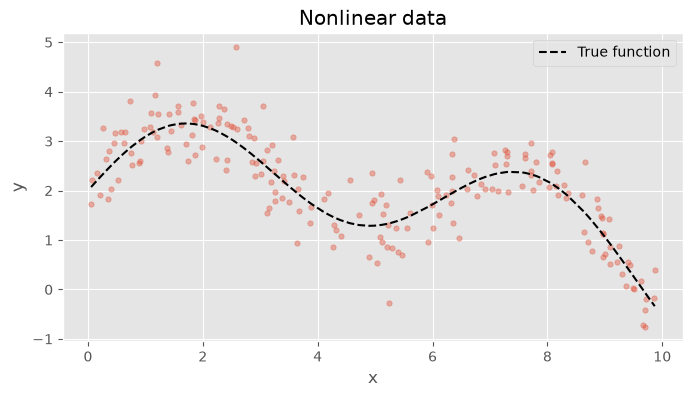

In [2]:
np.random.seed(42)
n = 200
x = np.sort(np.random.uniform(0, 10, n))
y_true = np.sin(x) + 0.3 * x - 0.05 * x**2 + 2
y = y_true + np.random.normal(0, 0.5, n)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.4, s=15)
plt.plot(x, y_true, 'k--', label='True function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Nonlinear data')
plt.show()

## Polynomial Regression

Unlike linear regression, polynomial regression uses powers of $x$. For example, a quadratic polynomial regression formula looks something like this:

$y = \beta_0 + \beta_1x_1 + \beta_2x_1^2 + ...$

Quadratic components of polynomial regression enable us to create nonlinear curvatures.

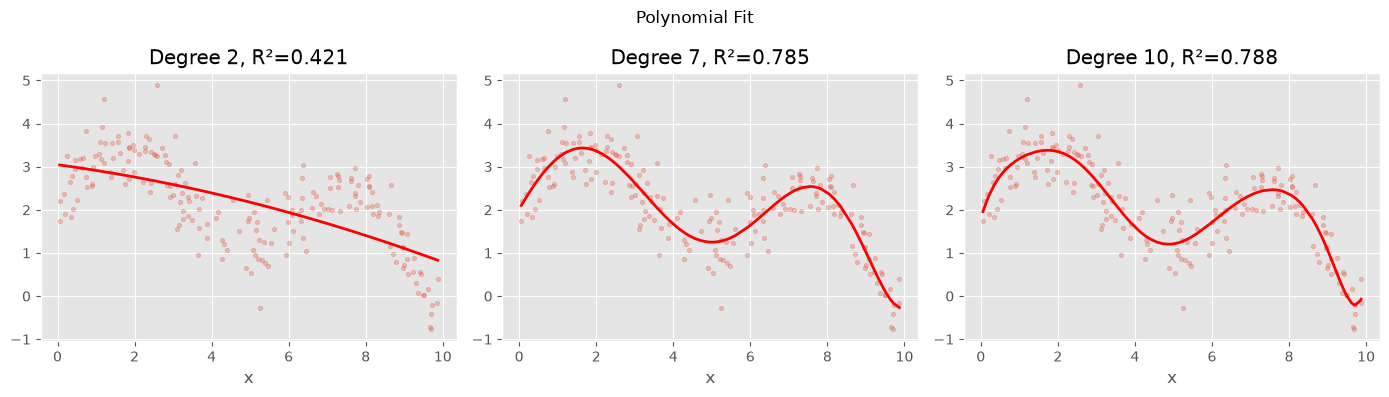

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, degree in zip(axes, [2, 7, 10]):
    X_poly = np.column_stack([x**i for i in range(1, degree + 1)])
    X_poly = sm.add_constant(X_poly)
    model_poly = sm.OLS(y, X_poly).fit()
    y_pred = model_poly.predict(X_poly)
    
    ax.scatter(x, y, alpha=0.3, s=10)
    ax.plot(x, y_pred, 'r-', linewidth=2)
    ax.set_title(f'Degree {degree}, R²={model_poly.rsquared:.3f}')
    ax.set_xlabel('x')

plt.suptitle('Polynomial Fit')
plt.tight_layout()
plt.show()

As we increase the degree of the model, it captures the pattern better. 


The downsides of polynomial regression are the following:

- A couple of local outliers can skew the model as a whole.
- As degrees increase, the model tends to fit poorly at the start and end, since most of the time there are fewer data points in those regions.


Spline regression is a way to combat this problem. 

## Spline Regression

Spline Regression is basically a set of *piecewise* polynomial fits that are joined smoothly at specific points called **knots**.



### Linear Splines

The simplest spline is piecewise linear regression. At each knot, the slope is allowed to change. The model is:

$f(x) = \beta_0 + \beta_1 x + \sum_{k=1}^{K} \beta_{k+1}(x - t_k)_+$

where $t_k$ are the knot locations and $(x - t_k)_+ = \max(0, x - t_k)$ is the "hinge" function. Let's fit one manually.

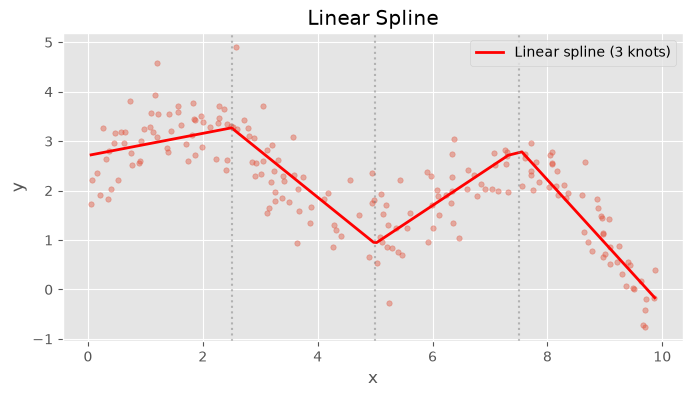

R2: 0.748


In [4]:
knots = [2.5, 5.0, 7.5]

# Build linear spline basis
X_lin = np.column_stack([x] + [np.maximum(0, x - t) for t in knots])
X_lin = sm.add_constant(X_lin)

model_lin = sm.OLS(y, X_lin).fit()
y_pred_lin = model_lin.predict(X_lin)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.4, s=15)
plt.plot(x, y_pred_lin, 'r-', linewidth=2, label='Linear spline (3 knots)')
for t in knots:
    plt.axvline(t, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Linear Spline')
plt.show()

print(f'R2: {model_lin.rsquared:.3f}')

Linear splines capture the general trend but produce sharp corners at the knots. The fit is not smooth. The first derivative is discontinuous at each knot (called *subgradient* in convex optimization). For most applications this is too crude.

### Cubic Splines

Cubic splines use third degree polynomials between knots. At each knot, the function, its first derivative, and second derivative are all continuous. This gives a visually smooth curve. The model is:

$f(x) = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \sum_{k=1}^{K} \gamma_k (x - t_k)_+^3$

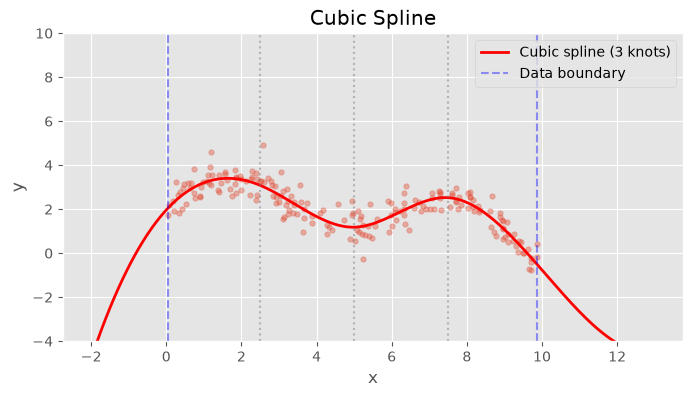

R2: 0.783
Parameters: 6


In [5]:
knots_cubic = [2.5, 5.0, 7.5]

X_cubic = np.column_stack(
    [x, x**2, x**3] + [np.maximum(0, x - t)**3 for t in knots_cubic])
X_cubic = sm.add_constant(X_cubic)

model_cubic = sm.OLS(y, X_cubic).fit()

x_ext = np.linspace(-2, 13, 400)
X_cubic_ext = np.column_stack(
    [x_ext, x_ext**2, x_ext**3] + [np.maximum(0, x_ext - t)**3 for t in knots_cubic])
X_cubic_ext = sm.add_constant(X_cubic_ext)
y_pred_ext = model_cubic.predict(X_cubic_ext)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.4, s=15)
plt.plot(x_ext, y_pred_ext, 'r-', linewidth=2, label='Cubic spline (3 knots)')
for t in knots_cubic:
    plt.axvline(t, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x.min(), color='blue', linestyle='--', alpha=0.4, label='Data boundary')
plt.axvline(x.max(), color='blue', linestyle='--', alpha=0.4)
plt.ylim(-4, 10)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Cubic Spline')
plt.show()

print(f'R2: {model_cubic.rsquared:.3f}')
print(f'Parameters: {model_cubic.df_model:.0f}')

Much smoother. But unrestricted cubic splines have a similar problem to polynomial fits; they *could* fit poorly in the tail regions where fewer data points constrain the polynomial. Also the extrapolated region is nonlinear which makes the predictions unstable.

To solve this problem, most of the time Restricted Cubic Splines (RCS for short) are used.

## Restricted Cubic Splines (Natural Splines)

RCS is similar to Cubic Splines. The only difference is that it forces the tail fits to be linear. By doing so,


- The redundant oscillations that *could* appear in the tail regions are prevented.
- The linear behaviour in tails also allows us to extrapolate better. 
- The number of parameters decreases. A linear fit requires far fewer parameters than a quadratic fit.

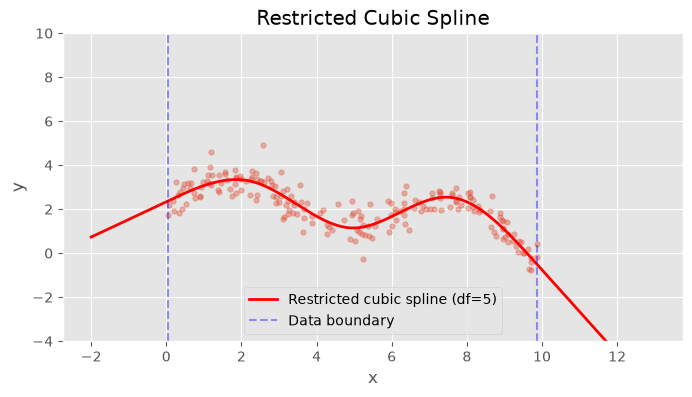

R2: 0.780
Parameters: 4


In [6]:
X_rcs = patsy.dmatrix('cr(x, df=5)', {'x': x}, return_type='dataframe')
model_rcs = sm.OLS(y, X_rcs).fit()

x_ext = np.linspace(-2, 13, 400)
design_info = X_rcs.design_info
X_rcs_ext = patsy.build_design_matrices(
    [design_info], {'x': x_ext}, return_type='dataframe')[0]
y_rcs_ext = model_rcs.predict(X_rcs_ext)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.4, s=15)
plt.plot(x_ext, y_rcs_ext, 'r-', linewidth=2, label='Restricted cubic spline (df=5)')
plt.axvline(x.min(), color='blue', linestyle='--', alpha=0.4, label='Data boundary')
plt.axvline(x.max(), color='blue', linestyle='--', alpha=0.4)
plt.ylim(-4, 10)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Restricted Cubic Spline')
plt.show()

print(f'R2: {model_rcs.rsquared:.3f}')
print(f'Parameters: {model_rcs.df_model:.0f}')

The RCS fit is comparable to the unrestricted cubic spline but with fewer parameters and better tail behavior. 

Because of that, RCS is recommended for most nonlinear regression modeling. ([Link](https://www.amazon.com/Regression-Modeling-Strategies-Applications-Statistics/dp/0387952322))

## Choosing the Number and Location of Knots

The exact location of knots rarely matters much. The recommended practice is:

- Place knots at fixed quantiles of the predictor's distribution. This ensures enough data in each segment.
- Use 4 knots at the 5th, 35th, 65th, and 95th percentiles as default.
- Use 3 knots (10th, 50th, 90th percentiles) for small samples ($n < 100$).
- Use up to 5 knots (5th, 27.5th, 50th, 72.5th, and 95th percentiles) for large samples ($n > 500$).

The reason we can use more knots as we have more data points is to prevent overfitting. We will see this in more detail in "Prespecifying Model Complexity" section.

The more knots we use, the more complex curvature we get. Let's see the effect of knots on curvature.

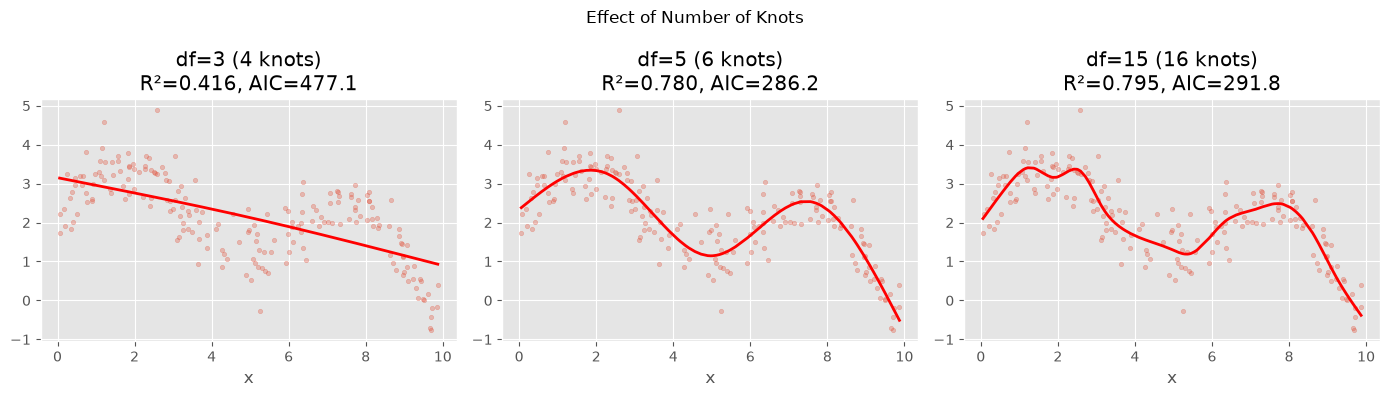

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, df in zip(axes, [3, 5, 15]):
    X_sp = patsy.dmatrix(f'cr(x, df={df})', {'x': x}, return_type='dataframe')
    model_sp = sm.OLS(y, X_sp).fit()
    y_pred = model_sp.predict(X_sp)
    
    ax.scatter(x, y, alpha=0.3, s=10)
    ax.plot(x, y_pred, 'r-', linewidth=2)
    ax.set_title(f'df={df} ({df+1} knots)\nR²={model_sp.rsquared:.3f}, AIC={model_sp.aic:.1f}')
    ax.set_xlabel('x')

plt.suptitle('Effect of Number of Knots')
plt.tight_layout()
plt.show()

## Splines in a Regression Model

In practice, we rarely use splines alone. More frequently, we use them in a regression model alongside the other variables.

Let's build a model which contains both linear and spline variables. Let's see an example. We will represent the `age` predictor nonlinearly and `bmi` linearly.

**Example**

$n = 300$

$\text{age} \sim U(20, 80)$

$\text{bmi} \sim \mathcal{N}(25,\ 4^2)$

The blood pressure depends on these predictors through the equation below:

$\text{bp} = 90 + 0.5\,\text{bmi} + 10\sin\!\left(\dfrac{\text{age}}{15}\right) + 0.3\,\text{age} + \varepsilon$

$\varepsilon \sim \mathcal{N}(0,\ 5^2)$

In [8]:
np.random.seed(123)
n = 300
age = np.random.uniform(20, 80, n)
bmi = np.random.normal(25, 4, n)
y_bp = 90 + 0.5 * bmi + 10 * np.sin(age / 15) + 0.3 * age + np.random.normal(0, 5, n)

df = pd.DataFrame({'age': age, 'bmi': bmi, 'bp': y_bp})

In [9]:
X_full = patsy.dmatrix('cr(age, df=5) + bmi', df, return_type='dataframe')
model_full = sm.OLS(df['bp'], X_full).fit()

print('\nSpline model:')
print(f'  R² = {model_full.rsquared:.3f}, AIC = {model_full.aic:.1f}')


Spline model:
  R² = 0.259, AIC = 1841.2


We can see the partial effect of `age` on `bp` by fixing the `bmi` variable to its mean. 

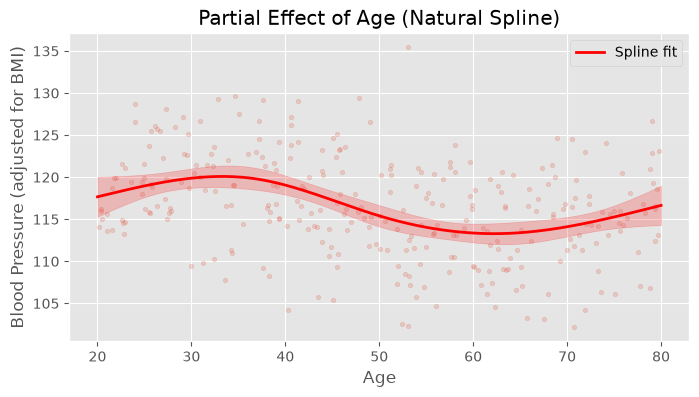

In [10]:
age_grid = np.linspace(20, 80, 200)
df_plot = pd.DataFrame({'age': age_grid, 'bmi': np.full(200, bmi.mean())})

X_plot = patsy.build_design_matrices([X_full.design_info], df_plot,
                                      return_type='dataframe')[0]
y_plot = model_full.predict(X_plot)

# Confidence band
pred = model_full.get_prediction(X_plot)
ci = pred.conf_int(alpha=0.05)

plt.figure(figsize=(8, 4))
plt.plot(age_grid, y_plot, 'r-', linewidth=2, label='Spline fit')
plt.fill_between(age_grid, ci[:, 0], ci[:, 1], alpha=0.2, color='red')
plt.scatter(df['age'], df['bp'], alpha=0.2, s=10)
plt.xlabel('Age')
plt.ylabel('Blood Pressure (adjusted for BMI)')
plt.title('Partial Effect of Age (Natural Spline)')
plt.legend()
plt.show()